In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import seaborn as sns
from scipy import stats



df = pd.read_csv('RainfallxFatalityRateTable.csv', sep = ",")
df.columns = ['Year', 'MONTH', 'ACCIDENTS', 'FATALITIES', 'RAINFALL', 'RATE']

def load_data(file_path):
  df = pd.read_csv(file_path)
  df["ACCIDENTS"] = df["ACCIDENTS"].str.replace(",","").astype(float)
  return df

def explore_data(df):
  print ("=== HEAD ===")
  display(df.head())

  print ("\n=== INFO ===")
  df.info()

  print("\n=== DESCRIBE ===")
  display(df.describe())



df = load_data("RainfallxFatalityRateTable.csv")
explore_data(df)


=== HEAD ===


,YEAR,MONTH,ACCIDENTS,FATALITIES,RAINFALL,FATALITY RATE (FATALITIES/ACCIDENTS)
0,2020,1,11880.0,306,44.8,0.025758
1,2020,2,10925.0,292,71.6,0.026728
2,2020,3,10705.0,306,50.2,0.028585
3,2020,4,5776.0,244,38.6,0.042244
4,2020,5,8133.0,286,50.6,0.035165



=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   YEAR                                  60 non-null     int64  
 1   MONTH                                 60 non-null     int64  
 2   ACCIDENTS                             60 non-null     float64
 3   FATALITIES                            60 non-null     int64  
 4   RAINFALL                              60 non-null     float64
 5   FATALITY RATE (FATALITIES/ACCIDENTS)  60 non-null     float64
dtypes: float64(3), int64(3)
memory usage: 2.9 KB

=== DESCRIBE ===


,YEAR,MONTH,ACCIDENTS,FATALITIES,RAINFALL,FATALITY RATE (FATALITIES/ACCIDENTS)
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,2022.000000,6.500000,17290.400000,472.600000,34.318333,0.027652
std,1.426148,3.481184,4996.275895,137.219013,27.042669,0.003993
min,2020.000000,1.000000,5776.000000,233.000000,0.000000,0.020767
25%,2021.000000,3.750000,13411.250000,365.000000,15.600000,0.025221
50%,2022.000000,6.500000,17661.000000,469.000000,28.750000,0.027260
75%,2023.000000,9.250000,21058.250000,592.000000,48.175000,0.029116
max,2024.000000,12.000000,26757.000000,702.000000,115.200000,0.042244


YEAR,2020,2021,2022,2023,2024
MONTH,,,,,
1,11880.0,9417.0,12439.0,14998.0,16244.0
2,10925.0,9098.0,11418.0,11723.0,16420.0
3,10705.0,12355.0,13460.0,15372.0,18940.0
4,5776.0,11483.0,14898.0,18719.0,22642.0
5,8133.0,13265.0,18664.0,21398.0,22345.0
6,14121.0,17606.0,17373.0,22931.0,25240.0
7,17716.0,22083.0,19514.0,24255.0,25414.0
8,17741.0,21042.0,19699.0,23923.0,26757.0
9,15596.0,19935.0,19230.0,23202.0,26080.0


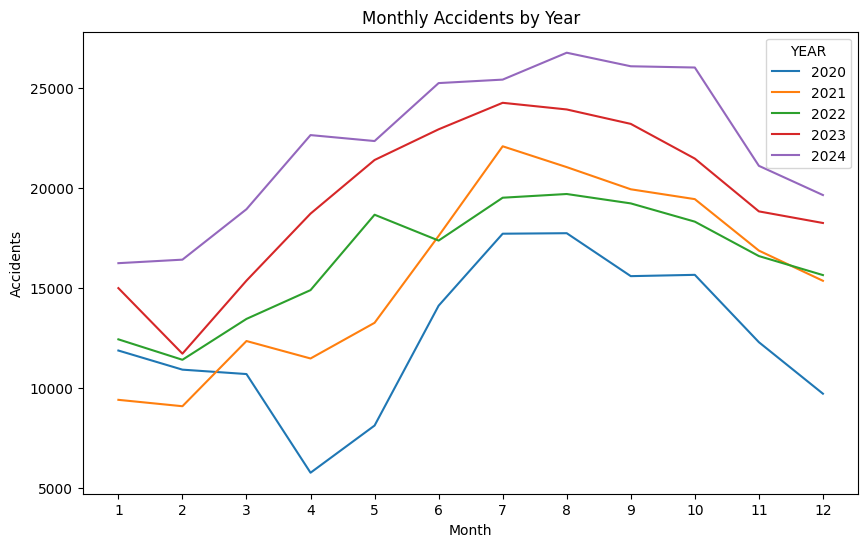

In [155]:
pivot_table = df.pivot(index="MONTH", columns="YEAR", values="ACCIDENTS")

display(pivot_table)

pivot_table.plot(figsize=(10,6))
plt.title("Monthly Accidents by Year")
plt.xlabel("Month")
plt.ylabel("Accidents")
plt.xticks(range(1,13))

plt.show()



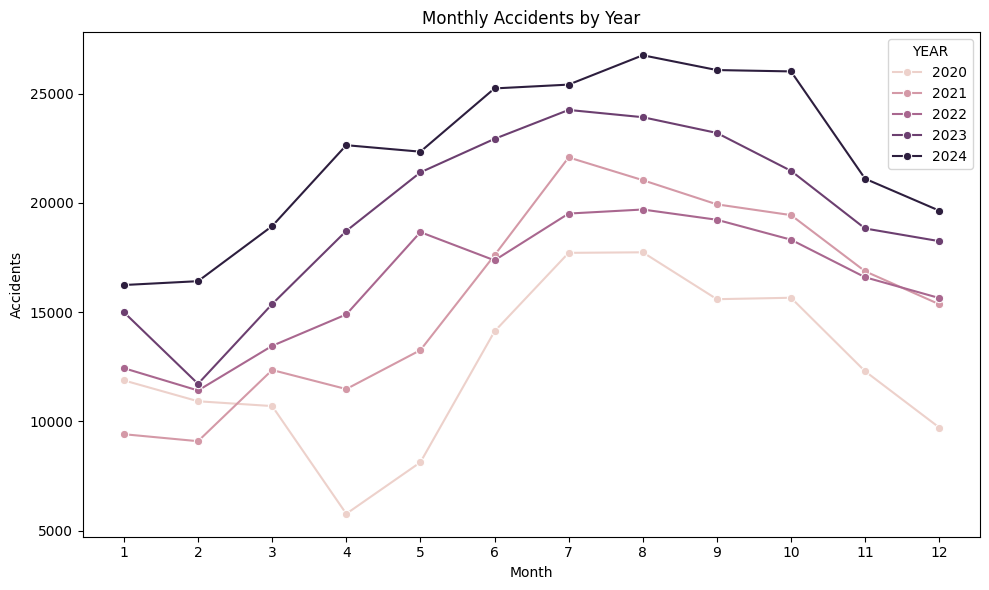

In [156]:
pivot_reset = pivot_table.reset_index()

pivot_melted = pivot_reset.melt(id_vars="MONTH", var_name="YEAR", value_name="ACCIDENTS")

plt.figure(figsize=(10,6))
sns.lineplot(data=pivot_melted, x="MONTH", y="ACCIDENTS", hue="YEAR", marker ="o")

plt.title("Monthly Accidents by Year")
plt.xlabel("Month")
plt.ylabel("Accidents")
plt.xticks(range(1,13))

plt.tight_layout()
plt.show()


YEAR,2020,2021,2022,2023,2024
MONTH,,,,,
1,44.8,43.5,75.0,16.4,56.4
2,71.6,28.2,25.6,27.2,11.4
3,50.2,60.7,72.9,115.2,49.0
4,38.6,60.5,23.7,77.3,37.9
5,50.6,19.0,43.2,45.4,111.2
6,39.8,26.2,51.2,103.6,10.2
7,0.0,1.9,2.0,5.3,15.6
8,0.0,32.7,0.0,2.2,5.6
9,0.2,50.7,16.0,15.6,26.3


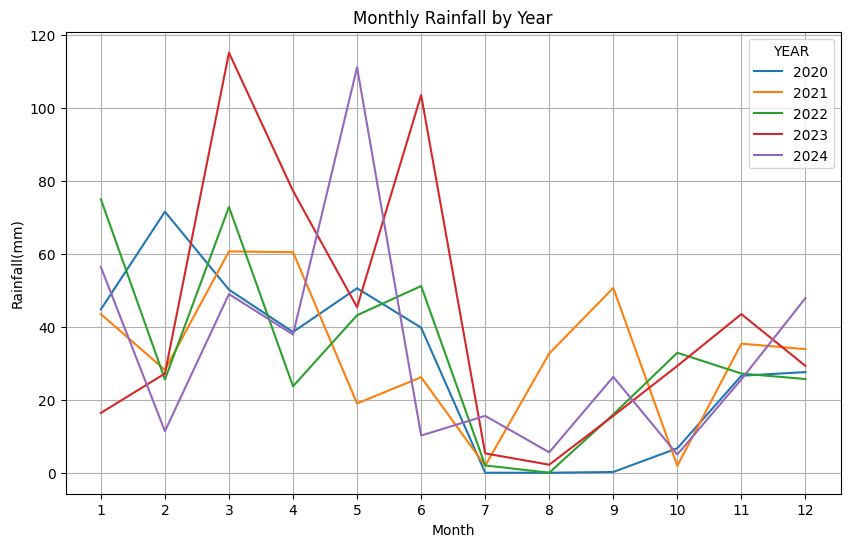

In [157]:
rainfall_pivot = df.pivot(index="MONTH", columns="YEAR", values="RAINFALL")

display(rainfall_pivot)

rainfall_pivot.plot(figsize=(10,6))

plt.title("Monthly Rainfall by Year")
plt.xlabel("Month")
plt.ylabel("Rainfall(mm)")


plt.xticks(range(1,13))
plt.grid(True)


plt.show()

,RAINFALL
MONTH,
1,47.22
2,32.80
3,69.60
4,47.60
5,53.88
6,46.20
7,4.96
8,8.10
9,21.76


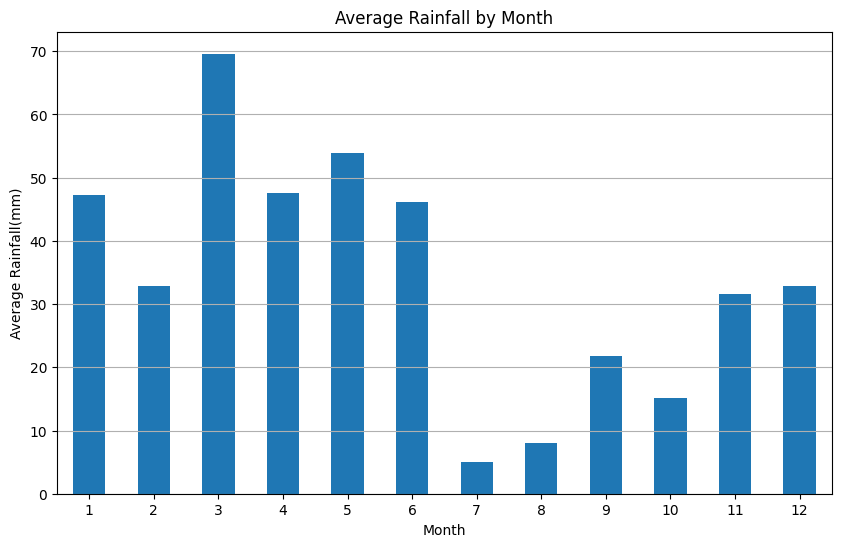

In [158]:
monthly_avg_rainfall = df.groupby("MONTH")["RAINFALL"].mean()

display(monthly_avg_rainfall)

monthly_avg_rainfall.plot(kind = "bar", figsize = (10,6))

plt.title("Average Rainfall by Month")
plt.xlabel("Month")
plt.ylabel("Average Rainfall(mm)")

plt.xticks(rotation = 0)
plt.grid(axis="y")

plt.show()

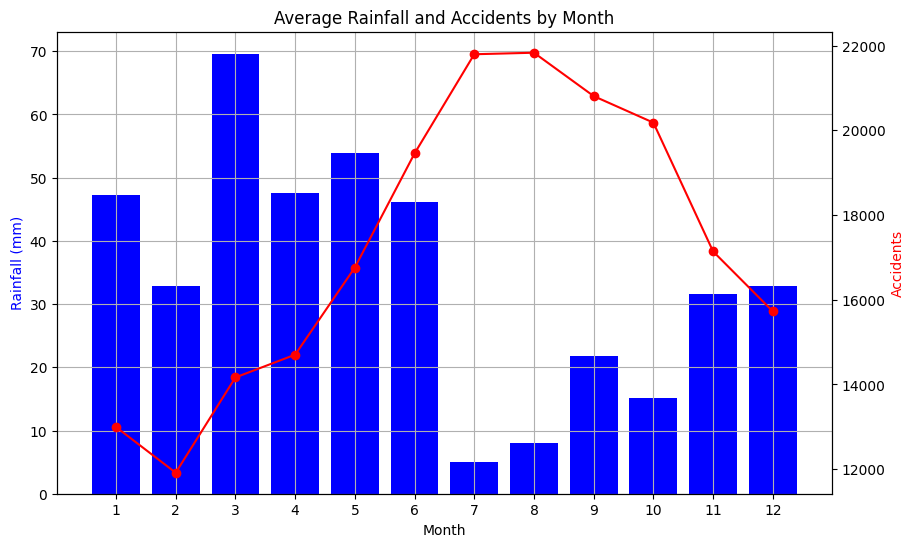

In [159]:
from ipywidgets import Label
monthly_avg_rainfall = df.groupby("MONTH")["RAINFALL"].mean()
monthly_avg_accidents = df.groupby("MONTH")["ACCIDENTS"].mean()

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(monthly_avg_rainfall.index, monthly_avg_rainfall.values, color="blue", label = "Average Rainfall")
ax1.set_ylabel("Rainfall (mm)", color = "blue")
ax1.set_xlabel("Month")

ax2 = ax1.twinx()
ax2.plot(monthly_avg_accidents.index, monthly_avg_accidents, color = "red", marker = "o", label = "Average Accidents")
ax2.set_ylabel ("Accidents", color="red")
plt.title("Average Rainfall and Accidents by Month")

ax1.set_xticks(range(1,13))
ax1.grid(True)
plt.show()


,ACCIDENTS
YEAR,
2020,150275.0
2021,187963.0
2022,197261.0
2023,235071.0
2024,266854.0


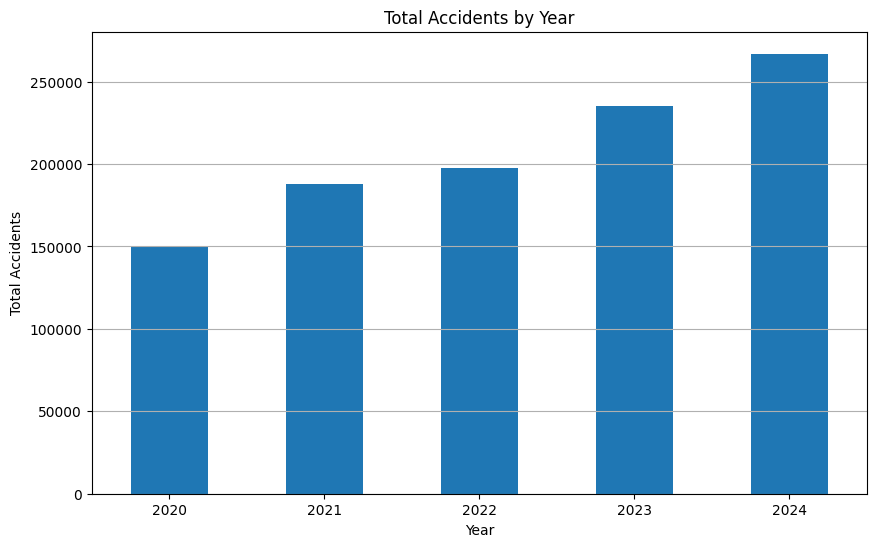

In [160]:
yearly_accidents = df.groupby("YEAR")["ACCIDENTS"].sum()
yearly_accidents

display(yearly_accidents)

yearly_accidents.plot(kind = "bar", figsize = (10,6))
plt.title ("Total Accidents by Year")
plt.xlabel ("Year")
plt.ylabel ("Total Accidents")

plt.xticks(rotation = 0)
plt.grid(axis="y")

plt.show()



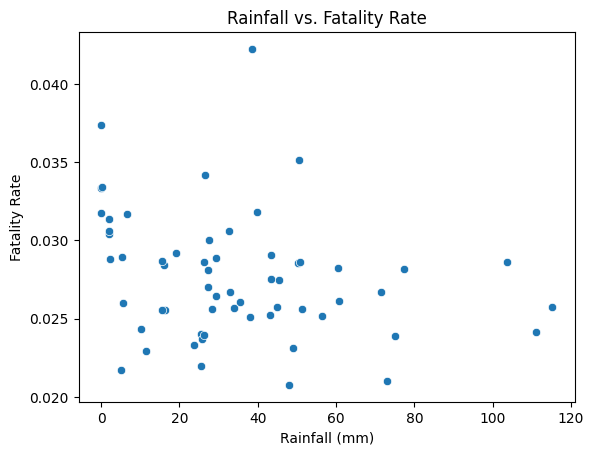

In [162]:
sns.scatterplot(x="RAINFALL", y="FATALITY RATE (FATALITIES/ACCIDENTS)", data=df)
plt.title("Rainfall vs. Fatality Rate")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Fatality Rate")

plt.show()

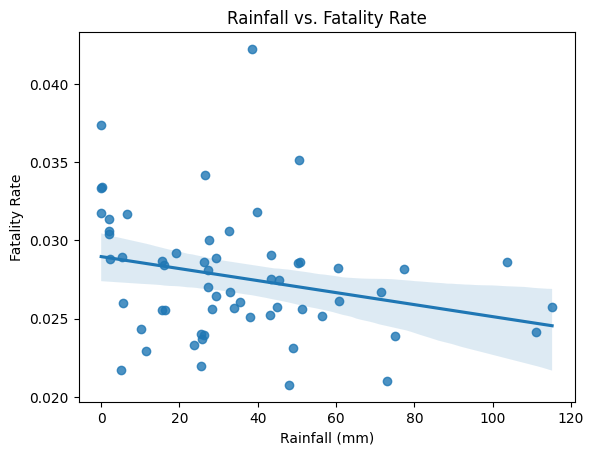

In [163]:
sns.regplot(x="RAINFALL", y="FATALITY RATE (FATALITIES/ACCIDENTS)", data=df)
plt.title("Rainfall vs. Fatality Rate")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Fatality Rate")

plt.show()

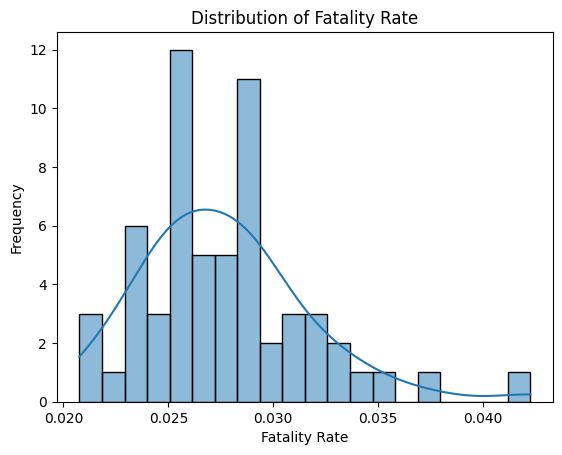

In [166]:
sns.histplot(data=df, x="FATALITY RATE (FATALITIES/ACCIDENTS)", bins=20, kde=True)
plt.title("Distribution of Fatality Rate")
plt.xlabel("Fatality Rate")
plt.ylabel("Frequency")

plt.show()

In [167]:
corr = df['RAINFALL'].corr(df['FATALITY RATE (FATALITIES/ACCIDENTS)'])
print("Correlation:", corr)

Correlation: -0.2598077272489296


# **PEARSON CORRELATION**
**A WEAK NEGATIVE CORRELATION (-0.26) WAS FOUND BETWEEN RAINFALL AND FATALITY RATE, THAT INDICATES HIGHER RAINFALL IS SLIGHTHLY RELATED TO FATALITY RATE. SO THERE IS NOT ENOUGH EVIDENCE TO ACCEPT H1 YET.**

In [169]:
threshold = df['RAINFALL'].median()
high = df[df['RAINFALL'] > threshold]
low = df[df['RAINFALL'] <= threshold]

t_stat, p_value = stats.ttest_ind(high['FATALITY RATE (FATALITIES/ACCIDENTS)'], low['FATALITY RATE (FATALITIES/ACCIDENTS)'])
print("T-stat", t_stat)
print("P-value", p_value)


T-stat -0.7160102613172212
P-value 0.4768579921905016


# T-TEST RESULT
**t-test showed that there is no statistically significant difference between high and low rainfall groups (p=0.477 > 0.05). Therefore it is not possible to say rainy days increase fatality rate. **

In [170]:
from sklearn.linear_model import LinearRegression

x = df[['RAINFALL']]
y = df['FATALITY RATE (FATALITIES/ACCIDENTS)']

model = LinearRegression()
model.fit(x, y)

print("Slope", model.coef_[0])
print("Intercept", model.intercept_)
print("R Square:", model.score(x, y))



Slope -3.8361022806738886e-05
Intercept 0.02896856836768927
R Square: 0.06750005513825419


# **LINEAR REGRESSION ANALYSIS**
**Linear regression shows a very weak negative relationship between rainfall and fatality rate. (R^2 = 0.067**) 

So it not possible to say rainfall explains accident fatality.

In [171]:
from scipy.stats import spearmanr

corr, p_value = spearmanr(df['RAINFALL'], df['FATALITY RATE (FATALITIES/ACCIDENTS)'])

print("Spearman's correlation coefficient:", corr)
print("P-value:", p_value)

Spearman's correlation coefficient: -0.2800333499312028
P-value: 0.030230263027429097


# **SPEARMAN CORRELATION**
**Spearman correlation indicated a weak negative relationship between rainfall and fatality rate (-0.28). Suggesting monotonic trend instead of strong linear relationship.**

# **CONCULISION**
**The initial hypothesis that rainfall increases fatality rate is not supported by the results. Instead, the analysis suggests a weak negative relationship, indicating that higher rainfall may be associated with slightly lower fatality rates.**